In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Configuração estética para publicações científicas
sns.set_theme(style="whitegrid", palette="tab10")
plt.rcParams.update(
    {
        "font.size": 11,
        "axes.titlesize": 13,
        "axes.titleweight": "bold",
        "axes.labelsize": 11,
        "figure.titlesize": 14,
    }
)

DATA_PATH = Path(
    "../data/processed/berlin/berlin_master_processed_1998_2025.parquet"
)

print("⏳ Carregando dataset processado da Maratona de Berlim...")
df_berlin = pd.read_parquet(DATA_PATH)

print(f"✅ Base carregada com sucesso!")
print(
    f"📊 Dimensões: {df_berlin.shape[0]:,} maratonistas x {df_berlin.shape[1]} colunas"
)
print(
    f"📅 Período coberto: {df_berlin['EventYear'].min()} a {df_berlin['EventYear'].max()} ({df_berlin['EventYear'].nunique()} edições)"
)
print(
    f"🚻 Distribuição por sexo:\n{df_berlin['GenderCode'].value_counts(dropna=False)}"
)

⏳ Carregando dataset processado da Maratona de Berlim...
✅ Base carregada com sucesso!
📊 Dimensões: 72,468 maratonistas x 62 colunas
📅 Período coberto: 1998 a 2025 (27 edições)
🚻 Distribuição por sexo:
GenderCode
M    55085
F    17367
X       16
Name: count, dtype: int64


--- RELATÓRIO: TAXA DE QUEBRA POR SEXO EM BERLIM (1998-2025) ---
GenderCode  Total_Atletas  Quebraram  Taxa_Quebra_Pct  Pacing_Ratio_Mediano  Tempo_Medio_Horas
         F          17367       1758            10.12              1.067768               4.52
         M          55085       9575            17.38              1.081880               4.05


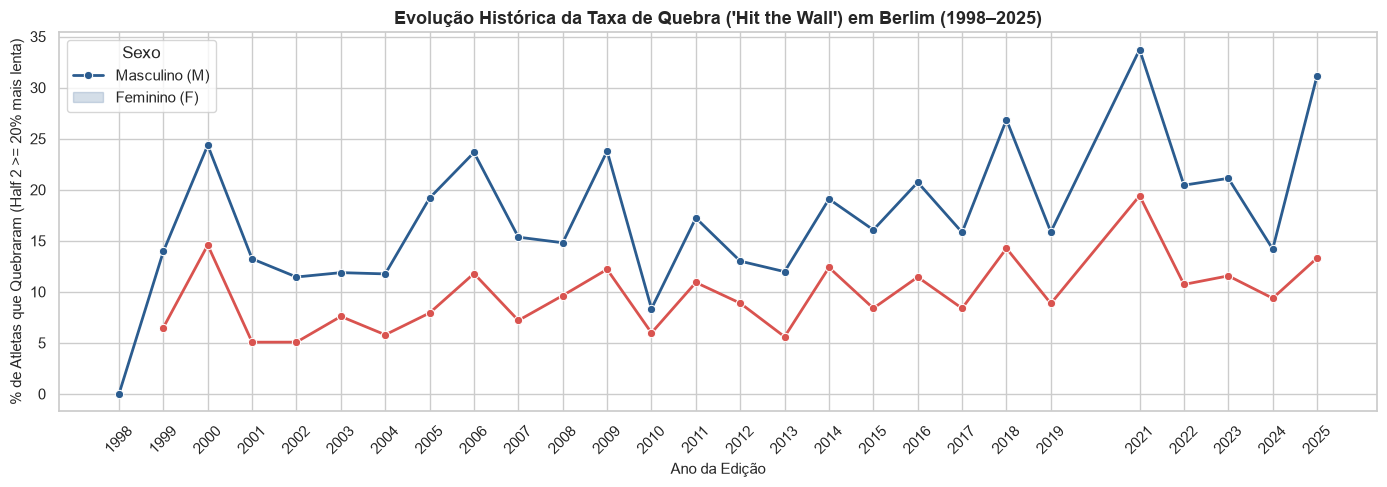

In [2]:
# 1. Tabela descritiva consolidada por sexo
wall_summary = (
    df_berlin[df_berlin["GenderCode"].isin(["M", "F"])]
    .groupby("GenderCode")
    .agg(
        Total_Atletas=("ID", "count"),
        Quebraram=("Hit_The_Wall", "sum"),
        Taxa_Quebra_Pct=("Hit_The_Wall", lambda x: (x.mean() * 100).round(2)),
        Pacing_Ratio_Mediano=("Pacing_Ratio", "median"),
        Tempo_Medio_Horas=(
            "ChipFinish_sec",
            lambda s: (s.mean() / 3600).round(2),
        ),
    )
    .reset_index()
)

print("--- RELATÓRIO: TAXA DE QUEBRA POR SEXO EM BERLIM (1998-2025) ---")
print(wall_summary.to_string(index=False))

# 2. Série temporal histórica da taxa de quebra por sexo
yearly_wall_berlin = (
    df_berlin[df_berlin["GenderCode"].isin(["M", "F"])]
    .groupby(["EventYear", "GenderCode"])["Hit_The_Wall"]
    .mean()
    .mul(100)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(14, 5))
gender_colors = {"M": "#2b5c8f", "F": "#d9534f"}

sns.lineplot(
    data=yearly_wall_berlin,
    x="EventYear",
    y="Hit_The_Wall",
    hue="GenderCode",
    hue_order=["M", "F"],
    palette=gender_colors,
    marker="o",
    linewidth=2,
    ax=ax,
)

ax.set_title(
    "Evolução Histórica da Taxa de Quebra ('Hit the Wall') em Berlim (1998–2025)",
    fontsize=13,
)
ax.set_ylabel("% de Atletas que Quebraram (Half 2 >= 20% mais lenta)")
ax.set_xlabel("Ano da Edição")
ax.set_xticks(sorted(df_berlin["EventYear"].unique()))
ax.set_xticklabels(sorted(df_berlin["EventYear"].unique()), rotation=45)
ax.legend(title="Sexo", labels=["Masculino (M)", "Feminino (F)"])

plt.tight_layout()
plt.show()

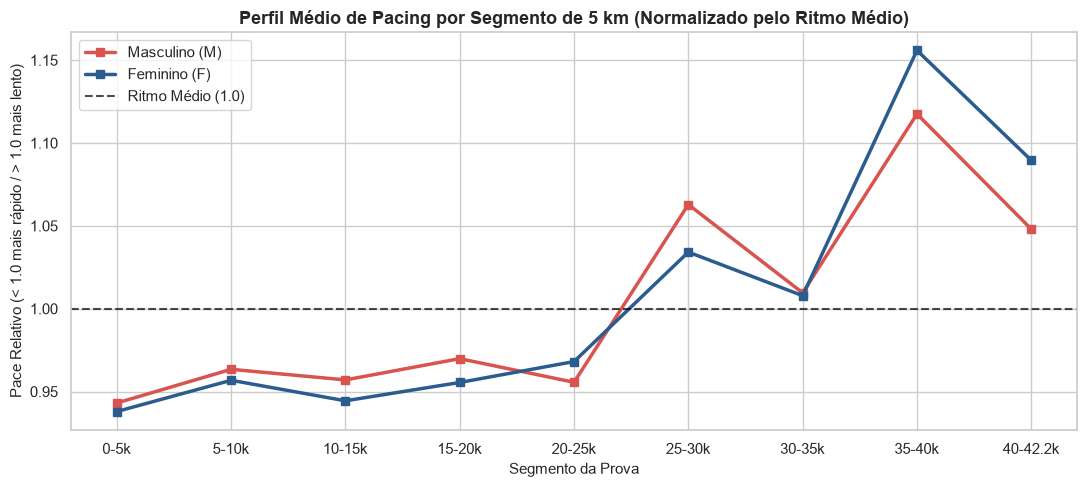

In [3]:
pace_cols = [
    "Pace_0_5k_min_per_km",
    "Pace_5_10k_min_per_km",
    "Pace_10_15k_min_per_km",
    "Pace_15_20k_min_per_km",
    "Pace_20_25k_min_per_km",
    "Pace_25_30k_min_per_km",
    "Pace_30_35k_min_per_km",
    "Pace_35_40k_min_per_km",
    "Pace_40_End_min_per_km",
]

split_labels = [
    "0-5k",
    "5-10k",
    "10-15k",
    "15-20k",
    "20-25k",
    "25-30k",
    "30-35k",
    "35-40k",
    "40-42.2k",
]

# Normalização de ritmo relativo: % de variação em relação ao pace médio da prova
df_valid_splits = df_berlin[
    df_berlin["GenderCode"].isin(["M", "F"])
    & (df_berlin["ChipFinish_sec"].between(7200, 21600))  # 2h a 6h
].copy()

# Cálculo do ritmo relativo (Pace do split / Pace geral)
for col in pace_cols:
    df_valid_splits[f"{col}_rel"] = (
        df_valid_splits[col] / df_valid_splits["Pace_Overall_min_per_km"]
    )

rel_pace_cols = [f"{col}_rel" for col in pace_cols]

pacing_profile = (
    df_valid_splits.groupby("GenderCode")[rel_pace_cols]
    .mean()
    .T.rename(index=dict(zip(rel_pace_cols, split_labels)))
)

fig, ax = plt.subplots(figsize=(11, 5))
pacing_profile.plot(
    kind="line",
    marker="s",
    linewidth=2.5,
    color={"M": "#2b5c8f", "F": "#d9534f"},
    ax=ax,
)

ax.axhline(
    1.0,
    color="black",
    linestyle="--",
    alpha=0.7,
    label="Ritmo Médio da Prova (1.0)",
)
ax.set_title(
    "Perfil Médio de Pacing por Segmento de 5 km (Normalizado pelo Ritmo Médio)",
    fontsize=13,
)
ax.set_ylabel("Pace Relativo (< 1.0 mais rápido / > 1.0 mais lento)")
ax.set_xlabel("Segmento da Prova")
ax.legend(
    ["Masculino (M)", "Feminino (F)", "Ritmo Médio (1.0)"], loc="upper left"
)
plt.tight_layout()
plt.show()

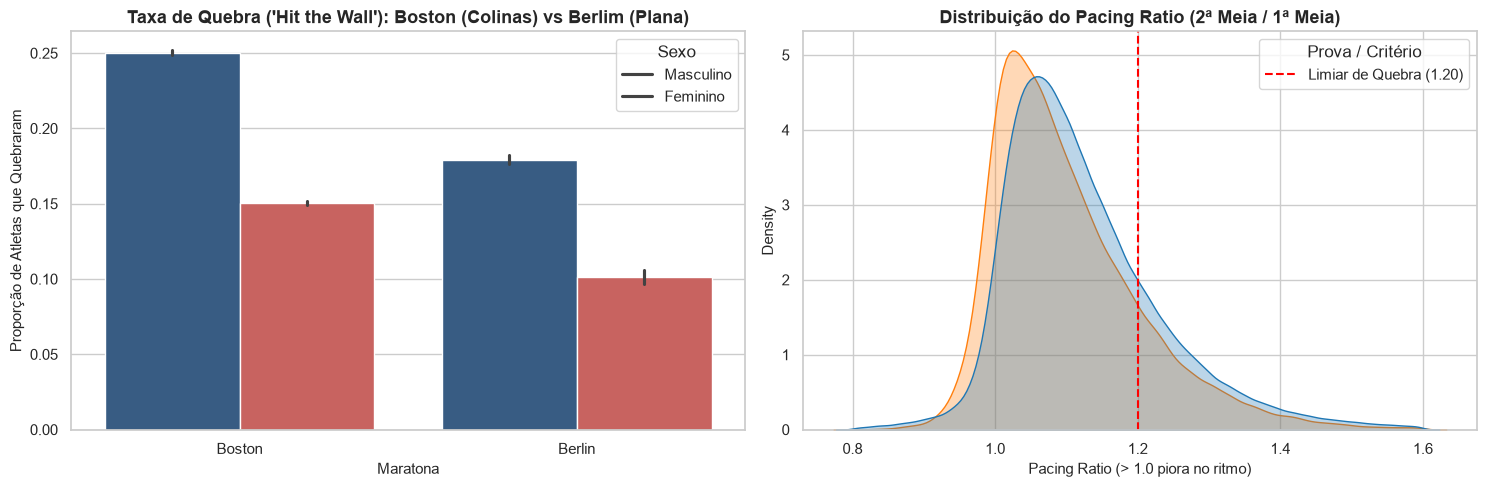

In [4]:
BOSTON_PATH = Path(
    "../data/processed/boston/boston_master_processed_2001_2026.parquet"
)

if BOSTON_PATH.exists():
    df_boston = pd.read_parquet(BOSTON_PATH)

    # Filtragem e unificação de amostragem
    cols_compare = [
        "Race",
        "EventYear",
        "GenderCode",
        "ChipFinish_sec",
        "Pacing_Ratio",
        "Hit_The_Wall",
    ]

    b_clean = df_boston[
        df_boston["GenderCode"].isin(["M", "F"])
    ][cols_compare].dropna()
    ber_clean = df_berlin[
        df_berlin["GenderCode"].isin(["M", "F"])
    ][cols_compare].dropna()

    df_comparison = pd.concat([b_clean, ber_clean], ignore_index=True)

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # 1. Taxa de quebra por Prova e Sexo
    sns.barplot(
        data=df_comparison,
        x="Race",
        y="Hit_The_Wall",
        hue="GenderCode",
        palette={"M": "#2b5c8f", "F": "#d9534f"},
        ax=axes[0],
    )
    axes[0].set_title(
        "Taxa de Quebra ('Hit the Wall'): Boston (Colinas) vs Berlim (Plana)"
    )
    axes[0].set_ylabel("Proporção de Atletas que Quebraram")
    axes[0].set_xlabel("Maratona")
    axes[0].legend(title="Sexo", labels=["Masculino", "Feminino"])

    # 2. Distribuição do Pacing Ratio
    sns.kdeplot(
        data=df_comparison[df_comparison["Pacing_Ratio"].between(0.8, 1.6)],
        x="Pacing_Ratio",
        hue="Race",
        common_norm=False,
        fill=True,
        alpha=0.3,
        palette={"Boston": "#1f77b4", "Berlin": "#ff7f0e"},
        ax=axes[1],
    )
    axes[1].axvline(
        1.20, color="red", linestyle="--", label="Limiar de Quebra (1.20)"
    )
    axes[1].set_title("Distribuição do Pacing Ratio (2ª Meia / 1ª Meia)")
    axes[1].set_xlabel("Pacing Ratio (> 1.0 piora no ritmo)")
    axes[1].legend(title="Prova / Critério")

    plt.tight_layout()
    plt.show()
else:
    print(
        "Dataset de Boston não localizado no caminho padrão para comparação."
    )

In [5]:
audit_berlin = pd.DataFrame(
    {
        "Critério de Auditoria": [
            "Total de Concluintes Analisados",
            "Atletas com Tapetes Faltantes (Possível Desvio)",
            "Atletas com Pace Impossível (< 2:30/km)",
            "Atletas com Negative Split Extremo (Half 2 < 75% da Half 1)",
            "Total com Alguma Inconsistência Detectada",
        ],
        "Ocorrências": [
            len(df_berlin),
            int(df_berlin["Flag_Missing_Mats"].sum()),
            int(df_berlin["Flag_Pace_Impossivel"].sum()),
            int(df_berlin["Flag_Negative_Split_Extremo"].sum()),
            int(
                df_berlin[
                    [
                        "Flag_Missing_Mats",
                        "Flag_Pace_Impossivel",
                        "Flag_Negative_Split_Extremo",
                    ]
                ]
                .any(axis=1)
                .sum()
            ),
        ],
        "% do Total": [
            100.0,
            (df_berlin["Flag_Missing_Mats"].mean() * 100).round(3),
            (df_berlin["Flag_Pace_Impossivel"].mean() * 100).round(3),
            (df_berlin["Flag_Negative_Split_Extremo"].mean() * 100).round(3),
            (
                df_berlin[
                    [
                        "Flag_Missing_Mats",
                        "Flag_Pace_Impossivel",
                        "Flag_Negative_Split_Extremo",
                    ]
                ]
                .any(axis=1)
                .mean()
                * 100
            ).round(3),
        ],
    }
)

print("--- RELATÓRIO DE INTEGRIDADE E AUDITORIA ÉTICA (BERLIM 1998-2025) ---")
print(audit_berlin.to_string(index=False))

--- RELATÓRIO DE INTEGRIDADE E AUDITORIA ÉTICA (BERLIM 1998-2025) ---
                                      Critério de Auditoria  Ocorrências  % do Total
                            Total de Concluintes Analisados        72468     100.000
            Atletas com Tapetes Faltantes (Possível Desvio)         1684       2.324
                    Atletas com Pace Impossível (< 2:30/km)         1985       2.739
Atletas com Negative Split Extremo (Half 2 < 75% da Half 1)            6       0.008
                  Total com Alguma Inconsistência Detectada         3669       5.063
